Evan Edelstein
EN.605.645.82.SP26

In [1]:
%matplotlib inline

In [2]:
import random
from typing import Dict, List, Tuple, Any
from math import exp, inf

# Module 13 - Programming Assignment

## Directions

1. Change the name of this file to be your JHED id as in `jsmith299.ipynb`. Because sure you use your JHED ID (it's made out of your name and not your student id which is just letters and numbers).
2. Make sure the notebook you submit is cleanly and fully executed. I do not grade unexecuted notebooks.
3. Submit your notebook back in Blackboard where you downloaded this file.

*Provide the output **exactly** as requested*

# The Problem

When we last left our agent in Module 4, it was wandering around a world filled with plains, forests, swamps, hills and mountains. This presupposes a map with known terrain:

```
......
...**.
...***
..^...
..~^..
```

but what if all we know is that we have some area of interest, that we've reduced to a GPS grid:

```
??????
??????
??????
??????
??????
```

and the agent has to determine what kind of terrain is to the left, front and right of it?

Assuming the agent has a very simple visual sensor that constructs a 4x4 grayscale image for each of the three directions, it might it could see something like this:

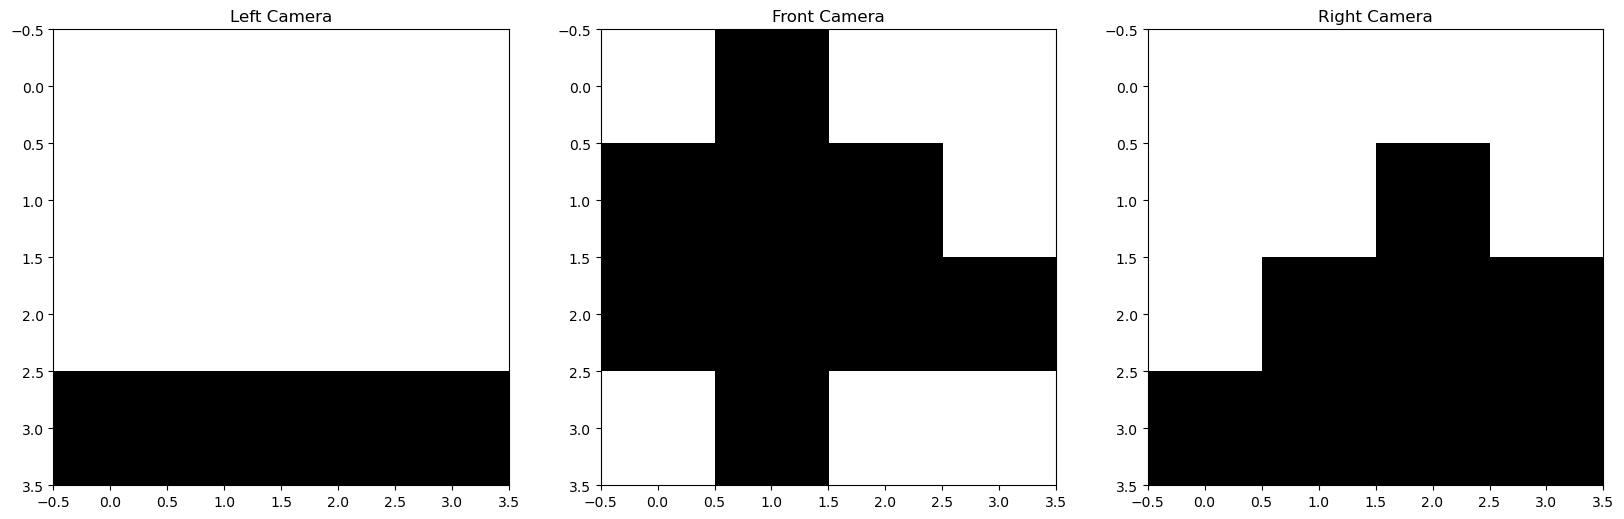

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import random

plain = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0]
forest = [0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0]
hills = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
swamp = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0]

figure = plt.figure(figsize=(20, 6))

axes = figure.add_subplot(1, 3, 1)
pixels = np.array([255 - p * 255 for p in plain], dtype="uint8")
pixels = pixels.reshape((4, 4))
axes.set_title("Left Camera")
axes.imshow(pixels, cmap="gray")

axes = figure.add_subplot(1, 3, 2)
pixels = np.array([255 - p * 255 for p in forest], dtype="uint8")
pixels = pixels.reshape((4, 4))
axes.set_title("Front Camera")
axes.imshow(pixels, cmap="gray")

axes = figure.add_subplot(1, 3, 3)
pixels = np.array([255 - p * 255 for p in hills], dtype="uint8")
pixels = pixels.reshape((4, 4))
axes.set_title("Right Camera")
axes.imshow(pixels, cmap="gray")

plt.show()
plt.close()

which would be plains, forest and hills respectively.


## The Assignment

In Assignment 12, we applied a logistic regression to determine if something was "hills" or "not hills". For this programming assignment your task is to write an artificial neural network that determines what kind of terrain it is. This is a multi-class problem.

For a starting point, you can refer to Pseudocode and the Self-Check.

## Data

As before, we have clean examples of the different types of terrain but based on the location, the registration can be a bit off for some of the types and the visual sensor is often blurry.

Here are the clean examples with different registrations: 

In [4]:
clean_data = {
    "plains": [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, "plains"]],
    "forest": [
        [0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, "forest"],
        [0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, "forest"],
        [1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, "forest"],
        [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, "forest"],
    ],
    "hills": [
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, "hills"],
        [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, "hills"],
        [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, "hills"],
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, "hills"],
    ],
    "swamp": [
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, "swamp"],
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, "swamp"],
    ],
}

Let's create a function that allows us to view any of these:

In [5]:
def view_sensor_image(data):
    figure = plt.figure(figsize=(4, 4))
    axes = figure.add_subplot(1, 1, 1)
    pixels = np.array([255 - p * 255 for p in data[:-1]], dtype="uint8")
    pixels = pixels.reshape((4, 4))
    axes.set_title("Left Camera:" + data[-1])
    axes.imshow(pixels, cmap="gray")
    plt.show()
    plt.close()

"I think that I shall never see a thing so lovely as a tree."

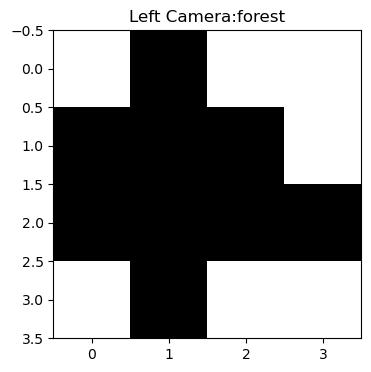

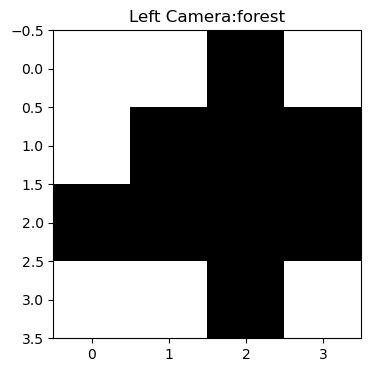

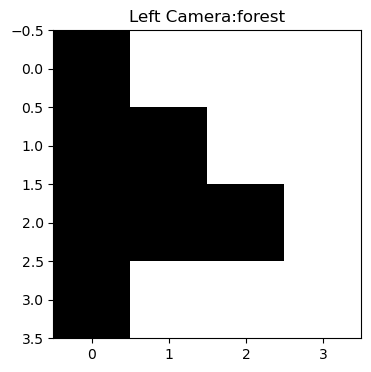

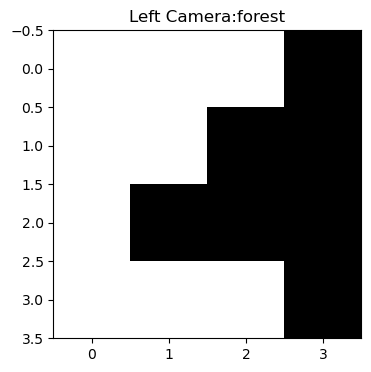

In [6]:
view_sensor_image(clean_data["forest"][0])
view_sensor_image(clean_data["forest"][1])
view_sensor_image(clean_data["forest"][2])
view_sensor_image(clean_data["forest"][3])

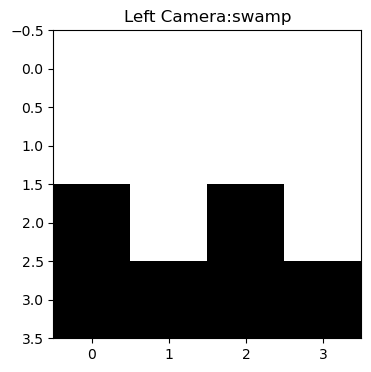

In [7]:
view_sensor_image(clean_data["swamp"][0])

The data that comes in, however, is noisy. The values are never exactly 0 and 1. In order to mimic this we need a `blur` function.

We will assume that noise is normally distributed. For values that should be 0, the noisy values are distributed $N(0.10, 0.05)$. For values should be 1, the noisy values are distributed $N(0.9, 0.10)$.

In [8]:
def blur(data):
    def apply_noise(value):
        if value < 0.5:
            v = random.gauss(0.10, 0.05)
            if v < 0.0:
                return 0.0
            if v > 0.75:
                return 0.75
            return v
        else:
            v = random.gauss(0.90, 0.10)
            if v < 0.25:
                return 0.25
            if v > 1.00:
                return 1.00
            return v

    noisy_readings = [apply_noise(v) for v in data[0:-1]]
    return noisy_readings + [data[-1]]

We can see how this affects what the agent *actually* sees.

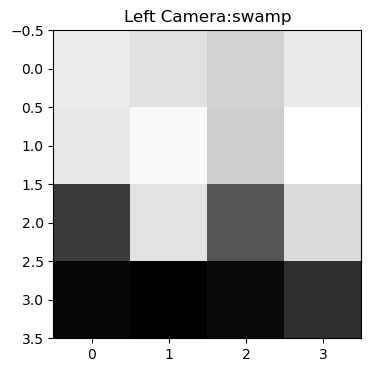

In [9]:
view_sensor_image(blur(clean_data["swamp"][0]))

You are going to want to write four (4) functions:

1. `generate_data`
2. `learn_model`
3. `apply_model`

### `generate_data`

With the clean examples and the `blur` function, we have an unlimited amount of data for training and testing our classifier, an ANN that determines if a sensor image is hills, swamp, forest or plains.

In classification, there is a general problem called the "unbalanced class problem". In general, we want our training data to have the same number of classes for each class. This means you should probably generate training data with, say, 100 of each type.

But what do we do about the class label with the neural network?

In this case, we can do "one hot". Instead of `generate_data` outputing a single 0 or 1, it should output a vector of 0's and 1's so that $y$ is now a vector as well as $x$. We can use the first position for hill, the second for swamp, the third for forest and the fourth for plains:

```
[0, 1, 0, 0]
```

what am I? swamp.

Unlike logistic regression, you should set the *biases* inside the neural network (the implict $x_0$ = 1) because there are going to be lot of them (one for every hidden and output node).

`generate_data` now only needs to take how many you want of each class:

`generate_data( clean_data, 100)`

generates 100 hills, 100 swamp, 100 forest, 100 plains and transforms $y$ into the respective "one hot" encoding. You can use the code from Module 12 as a starting point.

### `learn_model`

`learn_model` is the function that takes in training data and actually learns the ANN. If you're up to it, you can implement a vectorized version using Numpy but you might start with the loopy version first.

*In the lecture, I mentioned that you usually should mean normalize your data but you don't need to do that in this case because the data is already on the range 0-1.*

You should add a parameter to indicate how many nodes the hidden layer should have.

When verbose is True, you should print out the error so you can see that it is getting smaller.

When developing your algorithm, you need to watch the error so you'll set verbose=True to start. You should print it out every iteration and make sure it is declining. You'll have to experiment with both epsilon and alpha; and it doesn't hurt to make alpha adaptive (if the error increases, make alpha = alpha / 10).

When you know that your algorithm is working, change your code so that the error is printed out only every 1,000 iterations (it takes a lot of iterations for this problem to converge, depending on your parameter values--start early).

`learn_model` returns the neural network. The hidden layer will be one vector of thetas for each hidden node. And the output layer will have its own thetas, one for each output (4 in this case). Return it as a Tuple: (List of List, List of List).

### `apply_model`

`apply_model` takes the ANN (the model) and either labeled or unlabeled data. If the data is unlabeled, it will return predictions for each observation as a List of Tuples of the inferred value (0 or 1) and the actual probability (so something like (1, 0.73) or (0, 0.19) so you have [(0, 0.30), (1, 0.98), (0, 0.87), (0, 0.12)]. Note that unlike the logistic regression, the threshold for 1 is not 0.5 but which value is largest (0.98 in this case).

If the data is labeled, you will return a List of List of Tuples of the actual value (0 or 1) and the predicted value (0 or 1). For a single data point, you'll have the pairs of actual values [(0, 1), (0, 0), (0, 0), (1, 0)] is a misclassification and [(0, 0), (0, 0), (1, 1), (0, 0)] will be a correct classification. Then you have a List of *those*, one for each observation.

###  simple evaluation

We have an "unlimited" supply of data so we'll just generate a training set and then a test set and see how well our neural network does. Use the error rate (incorrect classifications/total examples) for your evaluation metric. We'll learn about more sophisticated 

1. generate training set (how many do you think you need?)
2. generate test set (how many is a good "test" of the network you built?)
3. loop over [2, 4, 8] hidden nodes:
    1. train model and apply to train data, calculate error rate.
    2. apply to test data and calculate error rate.
    3. print error rate
    
Which number of hidden nodes did best?

**As always when working with Lists or Lists of Lists, be very careful when you are modifying these items in place that this is what you intend (you may want to make a copy first)**

---

Put your helper functions above here.

## Main Functions

In [10]:
Model = Tuple[List[List[float]], List[List[float]]]

<a id="encode"></a>
## encode

*`encode` Encode a terrain string as a binary list using one-hot-encoding.* **Used By** [generate_data](#generate_data)

* **terrain** str - terrain to encode


**returns** List[int] | None - binary list encoding of the terrain or None if input is not a valid terrain

In [11]:
def encode(terrain: str) -> List[int] | None:
    terrain2bin = {
        "hills": [1, 0, 0, 0],
        "swamp": [0, 1, 0, 0],
        "forest": [0, 0, 1, 0],
        "plains": [0, 0, 0, 1],
    }

    return terrain2bin.get(terrain, None)

In [12]:
assert encode("hills") == [1, 0, 0, 0] # test 1 - proper encoding
assert encode("beaches") is None # test 2 - terrain not in list returns None
assert encode("") is None # test 3 - empty string returns None

<a id="decode"></a>
## decode

*`decode` Decode a binary list to a terrain string.* 

* **terrain_vector** List[int] - binary encoded terrain to decode


**returns** str | None - terrain string or None if input is not a valid terrain

In [13]:
def decode(terrain_vector: List[int]) -> str | None:
    if sum(terrain_vector) != 1 : 
        return None

    bin2terrain = ["hills", "swamp", "forest", "plains"]
    for i, terrain in zip(terrain_vector, bin2terrain):
        if i == 1:
            return terrain
    return None

In [14]:
assert decode([0, 0, 0, 1]) == "plains" # test 1 - proper decoding
assert decode([1, 1, 0, 0]) is None # test 2 - multiple selected terrain returns None
assert decode([0, 0, 0, 0, 1]) is None # test 3 - improper encoding returns None

### generate_data

Generates an endless supply of blurred data from a collection of terrain prototypes.

* `data`: Dict[Str, List[Any]] - a Dictionary of "clean" prototypes for each landscape type.
* `n`: Int - the number of blurred examples of each terrain type to return.

returns

* List[List[Any]] - a List of Lists. Each individual List is a blurred example of a terrain type, generated from the prototype.

In [15]:
def generate_data(data: Dict[str, List[Any]], n: int) -> List[Tuple[List[float], List[int] | None]]:
    result = []
    for _ in range(n):
        for terrain, prototypes in data.items():
            proto = random.choice(prototypes)
            row = blur(proto)
            encoded_terrain = encode(terrain)
            if encoded_terrain is None:
                continue
            result.append((row[:-1], encoded_terrain))
    return result

In [16]:
data = generate_data(clean_data, 0)
assert len(data) == 0  # test 1 - zero input returns no output

data = generate_data(clean_data, 10)
assert len(data) == 40  # test 2 - correct number of examples

data = generate_data({}, 10)
assert len(data) == 0  # test 3 - empty input returns empty output

<a id="sigmoid"></a>
## sigmoid

*`sigmoid` Apply the sigmoid function to an input $z$: $$s = \frac{1}{1+e^{-z}}$$* **Used By** [feed_forward](#feed_forward)

* **activation** float - activation value to apply sigmoid function to


**returns** float - result of sigmoid function

In [17]:
def sigmoid(activation: float) -> float:
    return 1.0 / (1.0 + exp(-1.0 * activation))

In [18]:
assert sigmoid(0) == 0.5  # test 1 - zero input
assert round(sigmoid(1), 3) == 0.731  # test 2 - positive input
assert round(sigmoid(-1), 3) == 0.269  # test 3 - negative input

<a id="feed_forward"></a>
## feed_forward

*`feed_forward` Given a feature vector, a list of weights for each hidden node and a list of weights for the output layer, calculate the activation value for each node. The activation of the output layer is the predicted value of the network. The activation for each node can be computed as: $$z = \sum{\theta_i * x_i}$$ for each weight $i$. The sigmoid function is then computed as: $$s = \frac{1}{1+e^{-z}}$$ The hidden layer activation and output layer prediction are returned.* **Uses** [sigmoid](#sigmoid). **Used by** [backprop](#backprop)

* **features** List[float] - list of input features with prepended bias
* **theta_h** List[List[float]] - 2d list of weight (including bias) for each node in the hidden layer
* **theta_o** List[List[float]] - 2d list of weight (including bias) for each node in the output layer


**returns** Tuple[List[float], List[float]] | None - tuple containing a list holding activation value for each hidden node and a second list containing the prediction value for each node in the output layer or None is the number of features and weights do not align

In [19]:
def feed_forward(features: List[float], theta_h: List[List[float]], theta_o: List[List[float]]) -> Tuple[List[float], List[float]] | None:
    if len(theta_h[0]) != len(features):
        return None
    # activations = [bias, z_0, z_1 ..., z_h] is activation for each hidden node h in n_hidden
    activations = [1.0] + [sigmoid(sum([w_h * x_t for w_h, x_t in zip(weights, features)])) for weights in theta_h]

    if len(theta_o[0]) != len(activations):
        return None
    # predictions = [s0, s1, ... si ] is prediction for each output node i in n_outputs
    predictions = [sigmoid(sum([v_i * z_h for v_i, z_h in zip(weights, activations)])) for weights in theta_o]
    return activations, predictions


In [20]:
features = [1.0, 0.52, -0.97]
theta_h = [[0.01, 0.26, -0.42], [-0.05, 0.78, 0.19], [0.42, -0.23, 0.37]]
theta_o = [[0.2, 0.61, 0.12, -0.9], [0.3, 0.28, -0.34, 0.10]]
output = feed_forward(features, theta_h, theta_o)
assert output is not None  # test 1.a - features is correctly biased
activations, predictions = output
assert [round(a, 3) for a in activations] == [1.0, 0.635, 0.543, 0.485]  # test 1.b - proper activation values
assert [round(p, 3) for p in predictions] == [0.554, 0.585]  # test 1.c - proper prediction values


features = [0.52, -0.97]
output = feed_forward(features, theta_h, theta_o)
assert output is None  # test 2 - features is incorrectly biased


features = [1.0, 0.52, -0.97]
theta_o = [[0.61, 0.12, -0.9], [0.28, -0.34, 0.10]]
output = feed_forward(features, theta_h, theta_o)
assert output is None  # test 2 - output layer has incorrect number of weights


<a id="calculate_error"></a>
## calculate_error

*`calculate_error` calculate the error for each node in a network. For output nodes the error can be calculated by: $$ \delta^o = \hat{y} * (1-\hat{y}) * (y - \hat{y})$$ The error for each hidden node is given by: $$\delta^h = \hat{y} * (1 - \hat{y} ) * \sum_i{\theta^{o}_i * \delta^{o}_i}$$ for activation value $\hat{y}$ and output weight $\theta^{o}_i$ and output node error $\delta^{o}_i$ for each output node $i$.* **Used By** [backprop](#backprop)

* **activations** List[float] - activation value for each node in the hidden layer of the network
* **predictions** List[float] - activation (prediction) value for each node in the output layer of the network
* **label** List[float] - binary encoding of true terrain of the example
* **theta_o** List[List[float]] - 2d list of weight (including bias) for each node in the output layer

**returns** Tuple[List[float], List[float]] - tuple containing a list holding prediction error  for each hidden node and a second list containing the prediction error for each node in the output layer. None if returned if activations and theta_o to not align.

In [21]:
def calculate_error(activations: List[float], predictions: List[float], label: List[int], theta_o: List[List[float]]) -> Tuple[List[float], List[float]] | None:
    n_hidden_biased = len(activations)
    n_outputs = len(predictions)
    delta_o = [predictions[i] * (1 - predictions[i]) * (label[i] - predictions[i]) for i in range(n_outputs)]
    
    if n_hidden_biased != len(theta_o[0]):
        return None
    
    delta_h = []
    for h in range(n_hidden_biased - 1):
        output_value = sum([theta_o[i][h + 1] * delta_o[i] for i in range(n_outputs)])
        delta_h.append(activations[h + 1] * (1 - activations[h + 1]) * output_value)
    return delta_h, delta_o

In [22]:
theta_o = [[0.2, 0.61, 0.12, -0.9], [0.3, 0.28, -0.34, 0.10]]
activations, predictions = [1.0, 0.635, 0.543, 0.485], [0.554, 0.585]
label = [1, 0]
output  = calculate_error(activations, predictions, label, theta_o)
assert output is not None
delta_h, delta_o = output
assert [round(dh, 3) for dh in delta_h] == [0.006, 0.015, -0.028] # test 1 - proper delta_h
assert [round(do, 3) for do in delta_o] == [0.11, -0.142] # test 2 - proper delta_o

theta_o = [[0.2, 0.61, 0.12, -0.9], [0.3, 0.28, -0.34, 0.10]]
activations, predictions = [0.635, 0.543, 0.485], [0.554, 0.585]
label = [1, 0]
output  = calculate_error(activations, predictions, label, theta_o)
assert output is None # test 3 - activation is unbiased 

<a id="update_weights"></a>
## update_weights

*`update_weights` Given an input feature vector, a list of hidden node activation values, a list of weights and errors for the hidden layer and output layer and a learning rate, update the weights for the output and hidden nodes by the equations: $$\theta^{o}_{i,h} = \theta^{o}_{i,h} + alpha * \delta^{o}_i * activations_h$$ and $$\theta^{o}_{h,j} = \theta^{o}_{h,j} + alpha * \delta^{h}_h * features_j$$ for $i$ output nodes, $h$ hidden nodes (including output bias) and $j$ input nodes (including hidden bias).* **Used By** [backprop](#backprop)


* **features** List[float] - list of input features with prepended bias
* **activations** List[float] - activation value for each node in the hidden layer of the network
* **theta_h** List[List[float]] - 2d list of weight (including bias) for each node in the hidden layer
* **delta_h** List[float] - list of error for each node in the hidden layer
* **theta_o** List[List[float]] - 2d list of weight (including bias) for each node in the output layer
* **delta_o** List[float]- list of error for each node in the output layer
* **alpha** float - learning rate 


**returns** Tuple[List[List[float]], List[List[float]]] | None - tuple containing a list holding weights for each hidden nodes and a list holding weights for each output nodes. None if returned if error and weights do not share the same dimensions

In [23]:
def update_weights(features: List[float], activations: List[float], theta_h: List[List[float]], delta_h: List[float], theta_o: List[List[float]], delta_o: List[float], alpha: float) -> Tuple[List[List[float]], List[List[float]]] | None:
    n_hidden = len(theta_h)
    n_outputs = len(theta_o)
    n_inputs_biased = len(theta_h[0])

    if len(delta_h) != n_hidden or len(delta_o) != n_outputs:
        return None

    for i in range(n_outputs):
        for h in range(n_hidden + 1):
            theta_o[i][h] += alpha * delta_o[i] * activations[h]

    for h in range(n_hidden):
        for j in range(n_inputs_biased):
            theta_h[h][j] += alpha * delta_h[h] * features[j]
    return theta_h, theta_o

In [24]:
features = [1.0, 0.52, -0.97]
activations, predictions = [1.0, 0.635, 0.543, 0.485], [0.554, 0.585]
theta_h = [[0.01, 0.26, -0.42], [-0.05, 0.78, 0.19], [0.42, -0.23, 0.37]]
theta_o = [[0.2, 0.61, 0.12, -0.9], [0.3, 0.28, -0.34, 0.10]]
delta_h = [0.006, 0.015, -0.028] 
delta_o = [0.11, -0.142] 
alpha = 0.01

output = update_weights(features, activations, theta_h, delta_h, theta_o, delta_o, alpha)
assert output is not None # test 1.a - proper output
theta_h, theta_o = output
assert [[round(th, 3) for th in weights] for weights in theta_h] == [[0.01, 0.26, -0.42], [-0.05, 0.78, 0.19], [0.42, -0.23, 0.37]] # test 1.b - proper theta_h
assert [[round(to, 3) for to in weights] for weights in theta_o] == [[0.201, 0.611, 0.121, -0.899], [0.299, 0.279, -0.341, 0.099]] # test 1.c - proper theta_o


delta_h = [0.015, -0.028] 
output = update_weights(features, activations, theta_h, delta_h, theta_o, delta_o, alpha)
assert output is None # test 2 - check delta_h and theta_h align

delta_h = [0.006, 0.015, -0.028] 
delta_o = [-0.142] 
output = update_weights(features, activations, theta_h, delta_h, theta_o, delta_o, alpha)
assert output is None # test 3 - check delta_o and theta_o align

<a id="backprop"></a>
## backprop

*`backprop` Given an input biased feature vector, a list of weights for the hidden layer and output layer and a learning rate, calculate the activation and prediction value for each node in the network using feed_forward, calculate the error of the network and update the weights.* **Uses** [feed_forward](#feed_forward), [calculate_error](#calculate_error) and [update_weights](#update_weights) **Used by** [learn_model](#learn_model)

* **features** List[float] - list of input features with prepended bias 
* **theta_h** List[List[float]] - 2d list of weight (including bias) for each node in the hidden layer
* **theta_o** List[List[float]] - 2d list of weight (including bias) for each node in the output layer
* **label** List[float] - binary encoding of true terrain of the example
* **alpha** float - learning rate 


**returns** Tuple[List[List[float]], List[List[float]], List[float]] | None - tuple containing a list holding weights for each hidden nodes, a list holding weights for each output nodes and a list of prediction values for each output node. None is returned if any input lengths are not aligned.

In [25]:
def backprop(features: List[float], theta_h: List[List[float]], theta_o: List[List[float]], label: List[int], alpha: float) -> Tuple[List[List[float]], List[List[float]], List[float]] | None:
    output = feed_forward(features, theta_h, theta_o)
    if output is None:
        return None
    
    activation, prediction = output

    output = calculate_error(activation, prediction, label, theta_o)
    if output is None:
        return None 
    
    delta_h, delta_o = output

    output = update_weights(features, activation, theta_h, delta_h, theta_o, delta_o, alpha)
    if output is None:
        return None
    
    theta_h, theta_o = output
    return theta_h, theta_o, prediction

In [26]:
features = [1.0, 0.52, -0.97]
activations, predictions = [1.0, 0.635, 0.543, 0.485], [0.554, 0.585]
theta_h = [[0.01, 0.26, -0.42], [-0.05, 0.78, 0.19], [0.42, -0.23, 0.37]]
theta_o = [[0.2, 0.61, 0.12, -0.9], [0.3, 0.28, -0.34, 0.10]]
delta_h = [0.006, 0.015, -0.028] 
delta_o = [0.11, -0.142] 
alpha = 0.01

output = backprop(features, theta_h, theta_o, label, alpha) 
assert output is not None
assert [[round(th, 3) for th in weights] for weights in theta_h] == [[0.01, 0.26, -0.42], [-0.05, 0.78, 0.19], [0.42, -0.23, 0.37]] # test 1 - proper theta_h
assert [[round(to, 3) for to in weights] for weights in theta_o] == [[0.201, 0.611, 0.121, -0.899], [0.299, 0.279, -0.341, 0.099]] # test 2 - proper theta_o
assert [round(p, 3) for p in predictions] == [0.554, 0.585]  # test 3 - proper prediction values

<a id="initialize_model"></a>
## initialize_model

*`initialize_model` Create a network model with a given number of input nodes, hidden nodes and output nodes. Each network is represented as a tuple with two layers, the first for the hidden layer and second for the output layer. Each layer is a list of nodes, each node is a list of weights, one for each node in the previous layer and one for the bias. The parameter, weight_range, gives the +/- range for which every weight is randomly initialized to.*  **Used by** [learn_model](#learn_model)

* **n_inputs** int - number of input nodes
* **n_hidden** int - number of hidden nodes
* **n_outputs** int - number of output nodes
* **weight_range** float - range for weight initialization 


**returns** Model- tuple containing a list holding weights for each hidden nodes, and a list holding weights for each output node.

In [27]:
def initialize_model(n_inputs: int, n_hidden: int, n_outputs: int, weight_range: float) -> Model:
    # weights from jth input +bias to hth hidden 
    theta_h = [[random.uniform(-weight_range, weight_range) for j in range(n_inputs + 1)] for h in range(n_hidden)]

    # weights from hth hidden + bias to ith output 
    theta_o = [[random.uniform(-weight_range, weight_range) for h in range(n_hidden + 1)] for i in range(n_outputs)]
    return theta_h, theta_o

In [28]:
n_inputs = 1
n_hidden = 3
n_outputs = 1
weight_range = 0.5
theta_h, theta_o = initialize_model(n_inputs, n_hidden, n_outputs, weight_range)
assert len(theta_h) == 3 and len(theta_h[0]) == 2 # test 1 - correct dimensions for theta_h
for nodes in theta_h:
    for weight in nodes:
        assert -0.5 < weight < 0.5  # test 2 - all weights between -/+ weight range

assert len(theta_o) == 1 and len(theta_o[0]) == 4 # test 3 - correct dimensions for theta_o

<a id="train_model"></a>
## train_model

*`train_model` Given a list of tuples containing input features and encoded terrains as training data and a network represented as a tuple of hidden and output weights, train the network using backpropagation with a learning rate alpha for each example in the training data. The error is calculated by $$error = \frac{1}{N} * \sum_{n}^{N}{\sum_{i}^{K}{(y_{n,i} * \hat{y}_{n,i})^2}}$$ for $N$ training example, $K$ output labels, output labels $y$  and output predictions $\hat{y}$.* **Uses** [backprop](#backprop) 

* **features** List[float] - list of input features
* **theta_h** List[List[float]] - 2d list of weight (including bias) for each node in the hidden layer
* **theta_o** List[List[float]] - 2d list of weight (including bias) for each node in the output layer
* **alpha** float- learning rate 


**returns** float - error or None if backpropagation failed.

In [29]:
def train_model(training: List[Tuple[List[float], List[int]]], theta_h: List[List[float]], theta_o: List[List[float]], alpha: float) -> float | None:
    if len(training) == 0:
        return None
    error = 0.0
    for features, label in training:
        input_layer = [1.0] + features # bias
        output = backprop(input_layer, theta_h, theta_o, label, alpha)
        if output is None:
            return None
        
        theta_h, theta_o, prediction = output
        error += sum([(y - y_hat) ** 2 for y, y_hat in zip(label, prediction)])
    error /= len(training)
    return error

In [30]:
data = [([0.52, -0.97], [1, 0])]
theta_h = [[0.01, 0.26, -0.42], [-0.05, 0.78, 0.19], [0.42, -0.23, 0.37]]
theta_o = [[0.2, 0.61, 0.12, -0.9], [0.3, 0.28, -0.34, 0.10]]
alpha = 0.01

error = train_model(data, theta_h, theta_o, alpha)
assert error is not None # test 1 - valid average error
assert round(error, 3) == 0.541 # test 2 - correct error value

error = train_model([], theta_h, theta_o, alpha)
assert error is None # test 3 - empty input returns None

<a id="learn_model"></a>
## learn_model

*`learn_model` Given a list of tuples containing input features and encoded terrains, construct a network with n_hidden hidden nodes and train the network using backpropagation with learning rate alpha for each example in the training data. The training is repeated until the change in average error of the training set is below epsilon or max_iterations occur. With verbose set, the average error of the training set is printed every print_freq iterations. The trained network, represented as a tuple containing a list of weights for each hidden nodes, and a list of weights for each output node is returned, or None if the model doesn't converge within max_iterations.* **Uses** [train_model](#train_model) and [initialize_model](#initialize_model)

* **training** List[Tuple[List[float], List[int]]] - list of tuples containing input features and encoded terrain 
* **n_hidden** int - number of hidden nodes
* **alpha** float- learning rate 
* **epsilon** float - error cutoff
* **weight_range** float - range for weight initialization 
* **max_iterations** int - maximum iterations of the algorithm
* **verbose** bool - if true print progress  
* **print_freq** int - report error for every nth iteration of the algorithm

**returns** Model | None- tuple containing a list holding weights for each hidden nodes, and a list holding weights for each output node or None if convergence was not reached or number of features and weights do not align.

In [31]:
def learn_model(training: List[Tuple[List[float], List[int]]], n_hidden: int, alpha: float = 0.01, epsilon: float = 10**-5, weight_range: float = 0.1, max_iterations: int = 10000, verbose: bool = False, print_freq: int = 1000) -> Model | None:
    n_inputs, n_outputs = len(training[0][0]), len(training[0][-1])
    theta_h, theta_o = initialize_model(n_inputs, n_hidden, n_outputs, weight_range)

    prev_error = inf
    for iteration in range(max_iterations):
        error = train_model(training, theta_h, theta_o, alpha)
        if error is None:
            return None

        if error > prev_error :
            alpha /= 10 

        if verbose and (iteration % print_freq == 0):
            print(f"{iteration}\t{error:.6f}")

        if abs(error - prev_error) < epsilon:
            return theta_h, theta_o
        prev_error = error
    return None

In [32]:
data = [([0.52, -0.97], [1, 0])]
model = learn_model(data, 3)
assert model is not None 
assert len(model[0]) == 3 and len(model[0][0]) == 3 # test 1 - correct dimensions for theta_h
assert len(model[1]) == 2 and len(model[1][0]) == 4 # test 2 - correct dimensions for theta_o

model = learn_model(data, 3, max_iterations=1)
assert model is None # test 3 - if model doesn't converge return None

<a id="apply_model"></a>
## apply_model

*`apply_model` Given a trained model, a list of tuples containing features and encoded terrains or None as test data, and wether the test data has labels, return a prediction/probability for each terrain in the test set. Each example in the test set is fed through the network using [feed_forward](#feed_forward). If labeled is true, the output contains a tuple with the first position 1 for the actual terrain and 0 otherwise, similarly the second value is 1 for the terrain with the highest probability, and zero otherwise. If labeled is unset, the first position of the tuple is set to 1 for the highest probability terrain and the second is the probability.* **Uses** [feed_forward](#feed_forward)

* **model** Model - trained network 
* **test_data** List[Tuple[List[float], List[int] | None]] - list of tuples containing input features and encoded terrain or None if data is unlabeled
* **labeled** bool - true if the test data contains the encode terrain or None


**returns** List[List[Tuple[Any, Any]]] | None - list of output tuples, one for each terrain, per training example. If labeled is true the tuples or of the form (actual, prediction), if not, they are of the form (prediction, probability). None is returned if number of features and weights do not align.

In [33]:
def apply_model(model: Model, test_data: List[Tuple[List[float], List[int] | None]], labeled: bool = False) -> List[List[Tuple[Any, Any]]] | None:
    result = []
    theta_h, theta_o = model
    n_outputs = len(theta_o)
    for features, label in test_data:
        output = feed_forward([1.0] + features, theta_h, theta_o)
        if output is None:
            return None
        _, predictions = output
        max_node, max_val = None, -inf
        for i, y_hat in enumerate(predictions):
            if y_hat > max_val:
                max_val, max_node = y_hat, i

        row = []
        for i in range(n_outputs):
            prediction = 1 if i == max_node else 0
            terrain_tuple = (prediction, predictions[i]) if labeled == False else (label[i], prediction)  # type: ignore
            row.append(terrain_tuple)
        result.append(row)
    return result

In [34]:
theta_h = [[0.01, 0.26, -0.42], [-0.05, 0.78, 0.19], [0.42, -0.23, 0.37]]
theta_o = [[0.2, 0.61, 0.12, -0.9], [0.3, 0.28, -0.34, 0.10]]
model = (theta_h, theta_o)
data = [([0.52, -0.97], [1, 0])]

result = apply_model(model , data, True)
assert result is not None # test 1.a - output is not None
assert result == [[(1, 0), (0, 1)]] # test 1.b - output is (actual, predicted)


result = apply_model(model , data, False)
assert result is not None # test 2.a - output is not None
assert (result[0][0][0], round(result[0][0][1], 3) ) == (0, 0.554) and (result[0][1][0], round(result[0][1][1], 3) ) == (1, 0.585) # test 2.b - output is (predicted, prob)

result = apply_model(model , [], False)
assert result == [] # test 3 - empty data returns empty list 

<a id="evaluate"></a>
## evaluate

*`evaluate` Given the output of [apply_model](#apply_model), calculate the error rate as $\frac{\#-of-incorrect-predictions}{\#-of-examples}$.* 


* **result** List[List[Tuple[int, int]]] -  list of output tuples, one for each terrain, per training example. The tuple has the first position 1 for the actual terrain and 0 otherwise, similarly the second value is 1 for the terrain with the highest probability, and zero otherwise.


**returns** float - error rate

In [35]:
def evaluate(result: List[List[Tuple[int, int]]]) -> float:
    miss = 0
    for row in result:
        if (1, 1) not in row:
            miss += 1
    return miss / len(result)

In [36]:
result = [[(0,0), (1,1)]]
assert evaluate(result) == 0.0 # test 1 - incorrect prediction 

result = [[(1,0), (0,1)]]
assert evaluate(result) == 1.0 # test 2 - correct prediction

result = [[(1,0), (0,1)], [(0,0), (1,1)]]
assert evaluate(result) == 0.5 # test 3 - 1 correct 1 incorrect 

Test out generate_data:

In [37]:
results = generate_data(clean_data, 10)
for result in results:
    print(result)

([0.05664880188948088, 0.0622364163352506, 0.1632473220991607, 0.13587195557203152, 0.15526035174857888, 0.11357752201324411, 0.03683263647327728, 0.06978011768932572, 0.09339452186492082, 0.05200519762778881, 0.07932202862474118, 0.11875331691401342, 1.0, 0.9202279769995251, 0.9167871830110924, 0.9461627320686428], [0, 0, 0, 1])
([0.13437135263149144, 0.8462517592148375, 0.18856566038717695, 0.0, 0.9283917033713545, 1.0, 0.8778491938495104, 0.06926745016762902, 0.8248589693888505, 1.0, 0.9405352894616972, 0.9015070120230195, 0.19747698351776413, 0.8515264824762027, 0.12488607661136086, 0.0786091440428415], [0, 0, 1, 0])
([0.152077683365906, 0.20190237475795342, 0.16042212301449085, 0.10669943332894388, 0.9450384821084974, 0.0, 0.1015816097126114, 0.10527132439621502, 0.6856343522679412, 0.9600516393764387, 0.11476173845485341, 0.010249134356432044, 0.8685995543523528, 0.9435599396913247, 0.9349733833183598, 0.10168731894554535], [1, 0, 0, 0])
([0.05100021674084228, 0.06795942773969865

Use `generate_data` to generate 100 blurred examples of each type (all four terrains).

In [38]:
train_data = generate_data(clean_data, 100)

Use `learn_model` to learn a ANN model for classifying sensor images as hills, swamps, plains or forest. **Set Verbose to True**

In [39]:
model = learn_model(train_data, 2, verbose=True)

0	0.908910
1000	0.184324
2000	0.086182
3000	0.020720


Use `generate_data` to generate 100 blurred examples of each terrain and use this as your test data.

In [40]:
test_data = generate_data(clean_data, 100)

Apply the model and evaluate the results.

In [41]:
assert model is not None
results = apply_model(model, test_data)

In [42]:
print(results)

[[(0, 3.865406786105354e-07), (0, 0.0012537098990022591), (0, 0.03029585586964697), (1, 0.9475032677165773)], [(0, 0.0504463349623751), (0, 2.761646252401403e-07), (1, 0.9775427251393614), (0, 4.058904774639047e-06)], [(1, 0.9733145270732024), (0, 0.04650883021675999), (0, 0.006455980881956372), (0, 6.218341339909352e-07)], [(0, 0.0021898803351978868), (1, 0.9391527338903715), (0, 4.130932736785166e-05), (0, 0.10223766851708727)], [(0, 3.2838025208037665e-06), (0, 0.044418323830768776), (0, 0.0022670259988407967), (1, 0.8949829378186542)], [(0, 0.050029493211819084), (0, 2.7197668037924185e-07), (1, 0.9777853436517606), (0, 4.0705077816389555e-06)], [(1, 0.9688332782146172), (0, 0.1794973261255549), (0, 0.0020340871623087337), (0, 1.3188772446544746e-06)], [(0, 0.16813206887038706), (1, 0.8726473166759833), (0, 0.00010414558666394462), (0, 0.0008424206705569046)], [(0, 1.0637114642338624e-06), (0, 0.005539038380397535), (0, 0.010575369645840988), (1, 0.9207110965622537)], [(0, 0.046538

In [43]:
results = apply_model(model, test_data, True)
for r in results:
    actual = decode([i[0] for i in r])
    pred = decode([i[1] for i in r])
    if pred != actual:
        print(actual, pred)

Now that you're pretty sure your algorithm works (the error rate during training is going down, and you can evaluate `apply_model` results for its error rate), you need to determine what the best number of hidden nodes is.

Try 2, 4, or 8 hidden nodes and indicate the best one. Follow the outline above under "Simple Evaluation".
In the "real world", you could 10 fold cross validation and validation curves to determine the number of hidden nodes and possibly if you needed one or two hidden layers.

In [44]:
dataset = generate_data(clean_data, 100)
test_set = generate_data(clean_data, 100000)
errors = []
for n_hidden in [2, 4, 8]:
    model = learn_model(dataset, n_hidden)  # type: ignore
    assert model is not None

    result = apply_model(model, dataset, True)
    error = evaluate(result)
    print(f"Training Error ({n_hidden} nodes): ", error)
    result = apply_model(model, test_set, True)
    error = evaluate(result)
    print(f"Learning Error ({n_hidden} nodes): ", error)
    print()
    errors.append((error, n_hidden))

min_error = min(errors, key= lambda x: x[0])
print(f"Network with {min_error[1]} hidden nodes had the lowest error")

Training Error (2 nodes):  0.0
Learning Error (2 nodes):  0.000315

Training Error (4 nodes):  0.0
Learning Error (4 nodes):  3.25e-05

Training Error (8 nodes):  0.0
Learning Error (8 nodes):  2.5e-05

Network with 8 hidden nodes had the lowest error


## Before You Submit...

1. Did you provide output exactly as requested?
2. Did you re-execute the entire notebook? ("Restart Kernel and Rull All Cells...")
3. If you did not complete the assignment or had difficulty please explain what gave you the most difficulty in the Markdown cell below.
4. Did you change the name of the file to `jhed_id.ipynb`?

Do not submit any other files.

The pseudocode from the office hours recording really helped me. I think it shifted my view to using indices instead of over-using enumerate loops.